In [1]:
# Environment Setup

# Check if running in Colab
drive = None  # Initialize drive variable
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab environment")
    # Mount Google Drive
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    drive = None  # Define drive in except block
    IN_COLAB = False
    print("Running in Local environment")

# Install required packages if needed
if IN_COLAB:
    print("Installing required packages for Colab...")
    !{sys.executable} -m pip install accelerate -U -q
    !pip install captum -q
    !pip install h5py pandas scikit-learn -q
else:
    print("Local environment detected. Please ensure required packages are installed.")
    print("Required packages: torch, torchvision, h5py, pandas, scikit-learn, accelerate (optional), captum (optional)")
    print("Install with: pip install torch torchvision h5py pandas scikit-learn")

Running in Local environment
Local environment detected. Please ensure required packages are installed.
Required packages: torch, torchvision, h5py, pandas, scikit-learn, accelerate (optional), captum (optional)
Install with: pip install torch torchvision h5py pandas scikit-learn


In [2]:

# ## 1. Imports & Configuration

import copy
import hashlib
import json
import os
import random
import shutil
import sys
import warnings
from collections import defaultdict
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

import h5py
import math
import numpy as np  # noqa: F401 (used in TextileDataset and set_seed)
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

# Helper function to set random seed (replaces transformers.set_seed)
def set_seed(seed: int = 42):
    """Set random seed for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Disable HDF5 file locking for better compatibility
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# --- Environment Setup ---
# Use the IN_COLAB variable from the first cell
if 'IN_COLAB' not in globals():
    try:
        from google.colab import drive
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

if IN_COLAB:
    COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/Colab_Notebooks/CHE1148/project_code/CHE1148_Defect_Detecting")
    PROJECT_ROOT = COLAB_PROJECT_ROOT
    runtime_mode = "colab_drive"
else:
    LOCAL_PROJECT_ROOT = Path("E:/Download/Pycharm/CHE1148_Defect_Detecting")
    PROJECT_ROOT = LOCAL_PROJECT_ROOT
    runtime_mode = "local"

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Project root not found: {PROJECT_ROOT}\nPlease check the path is correct for your environment.")

os.chdir(PROJECT_ROOT)
print(f"Runtime mode: {runtime_mode}")
print(f"Working directory: {os.getcwd()}")

# Path configuration
ROOT = PROJECT_ROOT
RAW = ROOT / "data" / "raw" / "textile"
PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "data" / "results"
PROCESSED.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)  # Create RESULTS directory

# File paths
TRAIN_H5, TRAIN_CSV = RAW / "train64.h5", RAW / "train64.csv"
TEST_H5, TEST_CSV = RAW / "test64.h5", RAW / "test64.csv"
OUT_H5, OUT_CSV = PROCESSED / "full64.h5", PROCESSED / "full64.csv"

# Device setup - Auto-detect available hardware accelerator
print("\n--- Device Detection ---")
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"CUDA is available! Using GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch, "backends") and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple MPS is available! Using GPU")
else:
    try:
        import torch_directml  # type: ignore
        device = torch_directml.device()
        print("DirectML is available! Using GPU")
    except ImportError:
        print("No GPU acceleration available. Using CPU.")
print(f"Using device: {device}\n")

#set random seed
set_seed(42)

def _require_file(path: Path) -> None:
    """Fail fast when a required file is missing."""
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")


def _normalize_label(x) -> str:
    return str(x).strip()


def print_class_counts(df: pd.DataFrame, title: str) -> None:
    """Print total rows and per-class distribution for the given dataframe."""
    if "indication_type" not in df.columns:
        print(f"[{title}] Missing column: indication_type")
        return

    vc = df["indication_type"].astype(str).str.strip().value_counts()
    print(f"\n[{title}] total_images={len(df)}")
    for k, v in vc.items():
        print(f"  {k}: {v}")


Runtime mode: local
Working directory: E:\Download\Pycharm\CHE1148_Defect_Detecting

--- Device Detection ---
CUDA is available! Using GPU: NVIDIA GeForce RTX 3060 Ti
Using device: cuda



In [3]:
# ## 2. Merge Raw Train/Test into Processed Full Dataset

def merge_data() -> None:
    """
    Merge separate train/test H5 and CSV files into a unified dataset.

    Outputs:
      - data/processed/full64.csv
      - data/processed/full64.h5
    """
    if OUT_H5.exists() and OUT_CSV.exists():
        print("Dataset already merged. Skipping merge.")
        return

    _require_file(TRAIN_CSV)
    _require_file(TEST_CSV)
    _require_file(TRAIN_H5)
    _require_file(TEST_H5)

    df_train = pd.read_csv(TRAIN_CSV)
    df_test = pd.read_csv(TEST_CSV)

    # Keep original split info
    df_train["original_split"] = "train"
    df_test["original_split"] = "test"

    full_df = pd.concat([df_train, df_test], ignore_index=True)
    full_df.to_csv(OUT_CSV, index=False)
    print(f"Saved merged CSV: {OUT_CSV}")

    with h5py.File(OUT_H5, "w") as f_out:
        with h5py.File(TRAIN_H5, "r") as f_tr, h5py.File(TEST_H5, "r") as f_te:
            tr_imgs = f_tr["images"]
            te_imgs = f_te["images"]

            total_shape = (tr_imgs.shape[0] + te_imgs.shape[0], *tr_imgs.shape[1:])
            dset = f_out.create_dataset("images", shape=total_shape, dtype="f")  # keep original dtype choice

            dset[: tr_imgs.shape[0]] = tr_imgs[:]
            dset[tr_imgs.shape[0] :] = te_imgs[:]

    print(f"Saved merged H5: {OUT_H5}")


In [4]:
# ## 3. MD5 Hashing & Duplicate Analysis

def get_h5_hashes(h5_path: Path, total_images: int, chunk_size: int = 5000) -> List[str]:
    """Generate MD5 fingerprints for all images in the H5 file."""
    hashes: List[str] = [""] * total_images
    print(f"Generating MD5 fingerprints for {total_images} images...")

    with h5py.File(h5_path, "r") as f:
        images = f["images"]
        for start in range(0, total_images, chunk_size):
            end = min(start + chunk_size, total_images)
            chunk = images[start:end]
            for i, img in enumerate(chunk):
                hashes[start + i] = hashlib.md5(img.tobytes()).hexdigest()

    return hashes


def analyze_duplicates() -> List[str]:
    """
    Identify exact duplicates via MD5 and check leakage across original splits.

    Output:
      - data/processed/duplicates_report.csv (if duplicates exist)
    """
    _require_file(OUT_CSV)
    _require_file(OUT_H5)

    df = pd.read_csv(OUT_CSV)
    with h5py.File(OUT_H5, "r") as f:
        total = int(f["images"].shape[0])

    all_hashes = get_h5_hashes(OUT_H5, total)

    hash_map: Dict[str, List[int]] = defaultdict(list)
    for idx, h in enumerate(all_hashes):
        hash_map[h].append(idx)

    dup_groups = {h: idxs for h, idxs in hash_map.items() if len(idxs) > 1}
    dup_rows = sum(len(idxs) for idxs in dup_groups.values())

    print(f"Duplicate groups={len(dup_groups)} | duplicate_rows={dup_rows}")

    if dup_groups:
        dup_indices = [i for idxs in dup_groups.values() for i in idxs]
        report_df = df.iloc[dup_indices].copy()
        report_df["md5"] = [all_hashes[i] for i in dup_indices]
        report_path = PROCESSED / "duplicates_report.csv"
        report_df.to_csv(report_path, index=False)
        print(f"Saved duplicates report: {report_path}")

        # Leakage check: same md5 appears in both original train and original test
        leakage = report_df.groupby("md5")["original_split"].nunique()
        if (leakage > 1).any():
            print("[WARNING] Data leakage detected across original splits (train/test)!")
        else:
            print("[SAFE] No leakage found among duplicates across original splits.")

    return all_hashes

In [5]:
# ## 4. Split Generation (Dedup per original split + Stratified Train/Val)

def create_clean_split(all_hashes: List[str], included_classes: List[str], train_factor: int, defect_ratio: float) -> None:
    """
    Remove internal duplicates within each original split and generate Train/Val/Test CSVs.
    Remove requested classes from training set before splitting into final train and validation sets.

    Outputs:
      - data/processed/train_split.csv
      - data/processed/val_split.csv
      - data/processed/test_split.csv
    """
    df = pd.read_csv(OUT_CSV).copy()
    df["abs_ptr"] = range(len(df))  # pointer into full64.h5
    df["md5"] = all_hashes
    df["indication_type"] = df["indication_type"].astype(str).str.strip()

    tr_df_raw = df[df["original_split"] == "train"].copy()
    te_df_raw = df[df["original_split"] == "test"].copy()

    # Deduplicate within each portion
    tr_before, te_before = len(tr_df_raw), len(te_df_raw)
    tr_df = tr_df_raw.drop_duplicates(subset="md5", keep="first")
    te_df = te_df_raw.drop_duplicates(subset="md5", keep="first")
    tr_removed, te_removed = tr_before - len(tr_df), te_before - len(te_df)
    total_removed = tr_removed + te_removed

    print(f"Duplicates removed (within split): train={tr_removed}, test={te_removed}, total={total_removed}")

    # Remove requested classes from intermediate training dataframe
    tr_df = tr_df[tr_df["indication_type"].isin(included_classes)]

    #sample desired fraction of defects
    reduced_tr_df = reduce_training_set(tr_df, included_classes, train_factor, defect_ratio)

    # Stratified split (Train -> Train/Val) based on unique image index
    unique_df = reduced_tr_df.drop_duplicates("index")[["index", "indication_type"]].copy()
    train_idx, val_idx = train_test_split(
        unique_df["index"],
        test_size=0.1,
        random_state=42,
        stratify=unique_df["indication_type"],
    )

    df_train = tr_df[tr_df["index"].isin(train_idx)].sample(frac=1, random_state=42)
    df_val = tr_df[tr_df["index"].isin(val_idx)].sample(frac=1, random_state=42)

    train_path = PROCESSED / "train_split.csv"
    val_path = PROCESSED / "val_split.csv"
    test_path = PROCESSED / "test_split.csv"

    df_train.to_csv(train_path, index=False)
    df_val.to_csv(val_path, index=False)
    te_df.to_csv(test_path, index=False)

    print(f"Datasets finalized: Train({len(df_train)}), Val({len(df_val)}), Test({len(te_df)})")

    # Requested reporting
    #print_class_counts(df, "FULL (merged)")
    #print_class_counts(tr_df_raw, "ORIG TRAIN (raw)")
    #print_class_counts(te_df_raw, "ORIG TEST (raw)")
    #print_class_counts(tr_df, "ORIG TRAIN (deduped)")
    #print_class_counts(te_df, "ORIG TEST (deduped)")
    print_class_counts(df_train, "TRAIN SPLIT")
    print_class_counts(df_val, "VAL SPLIT")
    #print_class_counts(te_df, "TEST SPLIT")

def reduce_training_set(dedup_df, included_classes: List[str], training_fact: int, defect_rat: float):
    # abort method if defect fraction is 0
    if defect_rat == 1 and training_fact == 0:
        return dedup_df

    # calculate number of good and defective samples
    num_good_samples = math.floor(8000/(2**training_fact))
    num_defect_samples = math.floor(num_good_samples * defect_rat)
    print("num good samples: ", num_good_samples)
    print("num defect samples: ", num_defect_samples)

    reduced_df = pd.DataFrame(columns=dedup_df.columns)

    # sample defects and concat to df
    for i in range(1,len(included_classes)):
        holder_df = dedup_df.loc[dedup_df["indication_type"] == included_classes[i]]
        sampled_df = holder_df.sample(n=num_defect_samples, random_state=42)
        reduced_df = pd.concat([reduced_df, sampled_df])

    # sample good and concat to df
    holder_df = dedup_df.loc[dedup_df["indication_type"] == included_classes[0]]
    sampled_df = holder_df.sample(n=num_good_samples, random_state=42)
    reduced_df = pd.concat([reduced_df, sampled_df])

    return reduced_df


In [6]:
# ## 5. Label Map

LABEL_MAP_JSON = PROCESSED / "label_map.json"
EXPECTED_CLASSES = [
    "good",
    "cut",
    "color",
    "metal_contamination",
    "hole",
    "thread",
]


def _validate_labels(observed: List[str], label_map: Dict[str, int]) -> None:
    unknown = sorted(set(observed) - set(label_map.keys()))
    if unknown:
        raise ValueError(
            "CSV contains unknown class names (not in label_map).\n"
            f"unknown_labels={unknown}\n"
            f"label_map_keys={sorted(label_map.keys())}"
        )


def build_label_map_from_full_csv(full_csv_path: Path) -> Dict[str, int]:
    """
    Build a stable label map.
    We read the CSV only to verify labels; the mapping order is fixed (EXPECTED_CLASSES).
    """
    df = pd.read_csv(full_csv_path)
    labels = set(df["indication_type"].astype(str).str.strip().unique().tolist())

    expected = set(EXPECTED_CLASSES)
    missing = sorted(expected - labels)
    extra = sorted(labels - expected)
    if missing or extra:
        warnings.warn(
            "full CSV labels do not match EXPECTED_CLASSES.\n"
            f"missing={missing}\n"
            f"extra={extra}\n"
            f"full_labels={sorted(labels)}"
        , UserWarning)

    expected_map = {name: i for i, name in enumerate(EXPECTED_CLASSES)}
    final_map = {k: expected_map[k] for k in labels if k in expected_map}
    return final_map


def load_or_create_label_map(PASSED_PATH: Path) -> Dict[str, int]:
    label_map = build_label_map_from_full_csv(PASSED_PATH)
    LABEL_MAP_JSON.write_text(
        json.dumps(label_map, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return label_map


def validate_split_labels(csv_path: Path, label_map: Dict[str, int]) -> None:
    df = pd.read_csv(csv_path)
    observed = df["indication_type"].astype(str).str.strip().unique().tolist()
    _validate_labels([_normalize_label(x) for x in observed], label_map)



In [7]:
# ## 6. PyTorch Dataset & Model

class TextileDataset(Dataset):
    def __init__(
        self,
        csv_path: Path,
        h5_path: Path,
        *,
        label_map: Optional[Dict[str, int]] = None,
        transform: Optional[Callable] = None,
        strict_labels: bool = True,
    ):
        self.df = pd.read_csv(csv_path)
        self.h5_path = str(h5_path)
        self.transform = transform
        self.archive = None
        self.label_map = dict(label_map)

        labels = [_normalize_label(x) for x in self.df["indication_type"].tolist()]
        if strict_labels:
            _validate_labels(labels, self.label_map)
        self.df["indication_type"] = labels

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        if self.archive is None:
            # Open once per worker process
            self.archive = h5py.File(self.h5_path, "r", swmr=True)

        row = self.df.iloc[idx]
        img_np = self.archive["images"][int(row["abs_ptr"])]

        # Convert to float32 and ensure 0.0-1.0 range
        if img_np.max() > 1.0:
            img_np = img_np.astype("float32") / 255.0
        else:
            img_np = img_np.astype("float32")

        # Ensure shape is (1, 64, 64)
        if img_np.ndim == 2:
            img_np = np.expand_dims(img_np, axis=0)
        elif img_np.ndim == 3 and img_np.shape[-1] == 1:
            img_np = np.transpose(img_np, (2, 0, 1))

        img_tensor = torch.from_numpy(img_np)

        if self.transform:
            img_tensor = self.transform(img_tensor)

        label = self.label_map[row["indication_type"]]

        return img_tensor, torch.tensor(label, dtype=torch.long)


class TextileResNet(nn.Module):
    def __init__(self, num_classes: int):
        super(TextileResNet, self).__init__()

        # Load pre-trained ResNet-18
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Adapt stem for 1x64x64 grayscale inputs
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)

        # Adapt output head for specific num_classes
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)


In [8]:
# ## 7. Training Utilities (Early Stopping)

class EarlyStopping:
    def __init__(self, patience: int = 5, verbose: bool = True, monitor: str = 'f1'):
        """
        Early stopping based on validation metric.
        
        Args:
            patience: Number of epochs to wait before stopping if no improvement
            verbose: Whether to print messages
            monitor: Metric to monitor ('f1' or 'loss'). 'f1' means higher is better, 'loss' means lower is better
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.monitor = monitor
        # For F1, higher is better, so initialize to 0
        # For loss, lower is better, so initialize to inf
        self.best_metric = 0.0 if monitor == 'f1' else float('inf')
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, metric: float, model: nn.Module) -> None:
        if self.monitor == 'f1':
            # F1: higher is better
            if metric > self.best_metric:
                self.best_metric = metric
                self.best_model_state = copy.deepcopy(model.state_dict())
                self.counter = 0
                if self.verbose:
                    print(f"Validation F1 improved to {metric:.4f}. Saving model weights.")
            else:
                self.counter += 1
                print(f"EarlyStopping counter: {self.counter} of {self.patience}")
                if self.counter >= self.patience:
                    self.early_stop = True
        else:
            # Loss: lower is better
            if metric < self.best_metric:
                self.best_metric = metric
                self.best_model_state = copy.deepcopy(model.state_dict())
                self.counter = 0
                if self.verbose:
                    print(f"Validation loss improved to {metric:.4f}. Saving model weights.")
            else:
                self.counter += 1
                print(f"EarlyStopping counter: {self.counter} of {self.patience}")
                if self.counter >= self.patience:
                    self.early_stop = True


def run_step(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    is_train: bool = True,
) -> Tuple[float, float]:
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += float(loss.item())
            preds = outputs.argmax(dim=1)
            total += int(labels.size(0))
            correct += int((preds == labels).sum().item())

    avg_loss = total_loss / max(len(loader), 1)
    acc = 100.0 * correct / max(total, 1)
    return avg_loss, acc


def compute_val_f1(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device
) -> float:
    """
    Compute macro F1 score on validation set.
    
    Returns:
        macro_f1: Macro-averaged F1 score
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute macro F1
    macro_f1, _, _, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    
    return macro_f1



In [9]:
# ## 11. Pengju's testing cell

# Full defect list
# ["good","cut","color","metal_contamination","hole","thread"]

# EXPERIMENT PARAMETERS
# "train_factor" is the exponent that will be applied to 2. The result of that exponent will divide the training set size (before validation splitting)
# "defect_ratio" is the ratio of defects per 1 good sample (must be between 0 and 1)
# "defect_classes" is the classes that will be included in training. Order of the list must be the same as the list above. Removing classes must be done in order from the end of the list.

scenarios = [
    {"train_factor": 4, "defect_classes": ["good","cut","color","metal_contamination","hole","thread"], "defect_ratio": 1},
    {"train_factor": 5, "defect_classes": ["good","cut","color","metal_contamination","hole","thread"], "defect_ratio": 1},
    {"train_factor": 6, "defect_classes": ["good","cut","color","metal_contamination","hole","thread"], "defect_ratio": 1},
    {"train_factor": 7, "defect_classes": ["good","cut","color","metal_contamination","hole","thread"], "defect_ratio": 1},
    {"train_factor": 8, "defect_classes": ["good","cut","color","metal_contamination","hole","thread"], "defect_ratio": 1},
    {"train_factor": 9, "defect_classes": ["good","cut","color","metal_contamination","hole","thread"], "defect_ratio": 1}

]
# Build processed dataset
merge_data()
hashes = analyze_duplicates()
final_results_list = []
experiment_list = []
confusion_maxtrix_df = pd.DataFrame()

# Initialize variables to avoid "may be undefined" warnings
label_map = None
train_label_map = None
model = None
test_ds = None
y_true = None
y_pred = None


for cfg in scenarios:
  experiment_vars = {'Model': 'ResNet18', 'Train Factor': cfg["train_factor"], 'Defect Ratio': cfg["defect_ratio"], '# of Classes': len(cfg["defect_classes"])}
  scenario_name = "-".join(str(value) for value in experiment_vars.values())

  create_clean_split(hashes, cfg["defect_classes"], cfg["train_factor"], cfg["defect_ratio"])
  label_map = load_or_create_label_map(OUT_CSV)       # Frozen label map
  train_label_map = load_or_create_label_map(PROCESSED / "train_split.csv")       # Training label map
  print(label_map)

  # --- LOCAL DESTINATION (for faster data loading) ---
  if IN_COLAB:
      LOCAL_DATA = Path("/content/data")
      LOCAL_DATA.mkdir(parents=True, exist_ok=True)

      # 1. Define source paths
      drive_h5 = PROCESSED / "full64.h5"
      drive_train_csv = PROCESSED / "train_split.csv"
      drive_val_csv = PROCESSED / "val_split.csv"
      drive_test_csv = PROCESSED / "test_split.csv"

      # 2. Copy them to the fast local SSD (in Colab)
      print("Copying H5 to local storage (this may take a minute)...")
      shutil.copy(str(drive_h5), LOCAL_DATA / "full64.h5")
      shutil.copy(str(drive_train_csv), LOCAL_DATA / "train_split.csv")
      shutil.copy(str(drive_val_csv), LOCAL_DATA / "val_split.csv")
      shutil.copy(str(drive_test_csv), LOCAL_DATA / "test_split.csv")
      print("Done! Data is now on local SSD.")
      
      # 3. Update paths for the Dataset calls
      LOCAL_H5 = LOCAL_DATA / "full64.h5"
      LOCAL_TRAIN_CSV = LOCAL_DATA / "train_split.csv"
      LOCAL_VAL_CSV = LOCAL_DATA / "val_split.csv"
      LOCAL_TEST_CSV = LOCAL_DATA / "test_split.csv"
  else:
      # For local environment, files are already local
      print("Using local data files directly.")
      
      # Use files directly from PROCESSED directory
      LOCAL_H5 = PROCESSED / "full64.h5"
      LOCAL_TRAIN_CSV = PROCESSED / "train_split.csv"
      LOCAL_VAL_CSV = PROCESSED / "val_split.csv"
      LOCAL_TEST_CSV = PROCESSED / "test_split.csv"

  # Updated Dataset initialization using Local SSD paths and TextileDataset
  train_ds = TextileDataset(csv_path=LOCAL_TRAIN_CSV, h5_path=LOCAL_H5, label_map=label_map)
  val_ds = TextileDataset(csv_path=LOCAL_VAL_CSV, h5_path=LOCAL_H5, label_map=label_map)
  test_ds = TextileDataset(csv_path=LOCAL_TEST_CSV, h5_path=LOCAL_H5, label_map=label_map)

  # Set num_workers based on environment
  num_workers = 0 if not IN_COLAB else 2  # Use 0 for local Windows to avoid multiprocessing issues
  
  train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=num_workers, pin_memory=True)
  val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=True)
  test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=True)

  # 4. Setup Model - Use the device detected earlier
  print(f"\nUsing device: {device}")

  model = TextileResNet(num_classes=len(label_map)).to(device)
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=5e-4)
  early_stopping = EarlyStopping(patience=3, verbose=True, monitor='f1')

  #train model
  print("Training Scenario:", experiment_vars)
  num_epochs = 20
  for epoch in range(num_epochs):
      train_loss, train_acc = run_step(model, train_loader, criterion, optimizer, device, is_train=True)
      val_loss, val_acc = run_step(model, val_loader, criterion, optimizer, device, is_train=False)
      
      # Compute validation F1 score
      val_f1 = compute_val_f1(model, val_loader, device)
      
      print(f"Epoch {epoch+1}/{num_epochs} |  Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | Val F1: {val_f1:.4f}")

      # Early stopping based on F1 score
      early_stopping(val_f1, model)
      if early_stopping.early_stop:
          print("Early stopping triggered.")
          break

  # Load best model for evaluation
  if early_stopping.best_model_state is not None:
      model.load_state_dict(early_stopping.best_model_state)

  print("Training Complete.")

  #save model
  MODELS = ROOT / "data" / "models" / scenario_name
  MODELS.mkdir(parents=True, exist_ok=True)
  torch.save(model.state_dict(), MODELS / "model.pth")

  # evaluate test set
  model.eval()
  y_true, y_pred = [], []
  with torch.no_grad():
      for imgs, labels in test_loader:
          imgs, labels = imgs.to(device), labels.to(device)
          outputs = model(imgs)
          preds = outputs.argmax(dim=1)
          y_true.extend(labels.cpu().numpy())
          y_pred.extend(preds.cpu().numpy())

  # 2. Get class names in the correct order
  class_names = [k for k, v in sorted(label_map.items(), key=lambda item: item[1])]

  # 3. Build the Matrix
  cm = confusion_matrix(y_true, y_pred)

  # save matrix to drive
  cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
  cm_df.index.name = 'Actual'
  cm_df.columns.name = 'Predicted'
  cm_df_name = "cm-"+scenario_name+".csv"
  cm_df.to_csv(RESULTS / cm_df_name)

  # Compute Metrics for Logging
  macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
  acc = accuracy_score(y_true, y_pred)

  metrics = {
      "accuracy": acc,
      "f1_macro": macro_f1,
      "precision_macro": macro_p,
      "recall_macro": macro_r
  }
  final_results_list.append(metrics)
  experiment_list.append(experiment_vars)

# ============================================================
  # Save Confusion Matrix for this scenario
  # 自动保存到：data/results/Resnet-18/
  # ============================================================
  cm = confusion_matrix(y_true, y_pred)
  inverse_label_map = {v: k for k, v in label_map.items()}
  class_names = [inverse_label_map[i] for i in range(len(label_map))]

  # Save Confusion Matrix as CSV
  cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
  cm_filename = f"cm-ResNet18-{cfg['train_factor']}-{cfg['defect_ratio']}-{len(cfg['defect_classes'])}.csv"
  cm_path = RESULTS / cm_filename
  cm_df.to_csv(cm_path)
  print(f"Saved Confusion Matrix CSV: {cm_path}")

  print(f"\nConfusion Matrix for scenario: {scenario_name}")
  print(cm_df)

  # Save Confusion Matrix Plot as PNG
  try:
      import matplotlib.pyplot as plt
      import seaborn as sns

      plt.figure(figsize=(10, 8))
      sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True,
                  xticklabels=class_names, yticklabels=class_names)
      plt.title(f'Confusion Matrix - {scenario_name}')
      plt.xlabel('Predicted Label')
      plt.ylabel('True Label')
      plt.tight_layout()

      cm_plot_path = RESULTS / cm_filename.replace('.csv', '.png')
      plt.savefig(cm_plot_path, dpi=150, bbox_inches='tight')
      print(f"Saved Confusion Matrix Plot: {cm_plot_path}")
      plt.close()
  except ImportError as e:
      print(f"Could not plot confusion matrix heatmap: {e}")

final_results_df = pd.concat([pd.DataFrame(final_results_list)], ignore_index=True)
experiment_list_df = pd.concat([pd.DataFrame(experiment_list)], ignore_index=True)
full_results_df = pd.concat([experiment_list_df, final_results_df], axis=1)
results_file_name = "results-resnet.csv"
full_results_df.to_csv(RESULTS / results_file_name, index=False)


Dataset already merged. Skipping merge.
Generating MD5 fingerprints for 96000 images...
Duplicate groups=391 | duplicate_rows=782
Saved duplicates report: E:\Download\Pycharm\CHE1148_Defect_Detecting\data\processed\duplicates_report.csv
[SAFE] No leakage found among duplicates across original splits.
Duplicates removed (within split): train=157, test=234, total=391
num good samples:  500
num defect samples:  500
Datasets finalized: Train(2700), Val(300), Test(47766)

[TRAIN SPLIT] total_images=2700
  cut: 450
  color: 450
  thread: 450
  hole: 450
  metal_contamination: 450
  good: 450

[VAL SPLIT] total_images=300
  metal_contamination: 50
  thread: 50
  hole: 50
  good: 50
  cut: 50
  color: 50
{'color': 2, 'metal_contamination': 3, 'good': 0, 'thread': 5, 'hole': 4, 'cut': 1}
Using local data files directly.

Using device: cuda
Training Scenario: {'Model': 'ResNet18', 'Train Factor': 4, 'Defect Ratio': 1, '# of Classes': 6}
Epoch 1/20 |  Val Loss: 0.9323 Acc: 68.33% | Val F1: 0.6924

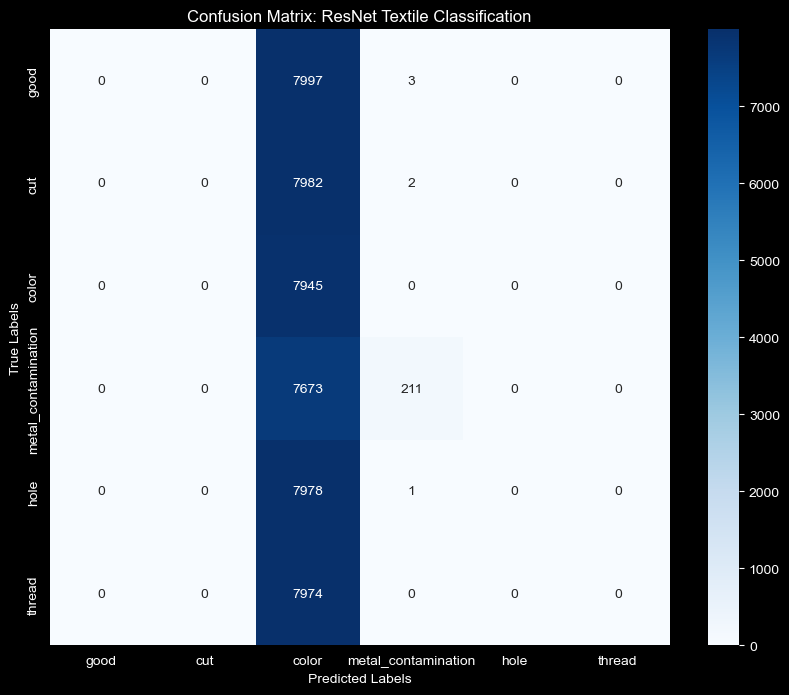


Detailed Classification Report:
                     precision    recall  f1-score   support

               good       0.00      0.00      0.00      8000
                cut       0.00      0.00      0.00      7984
              color       0.17      1.00      0.29      7945
metal_contamination       0.97      0.03      0.05      7884
               hole       0.00      0.00      0.00      7979
             thread       0.00      0.00      0.00      7974

           accuracy                           0.17     47766
          macro avg       0.19      0.17      0.06     47766
       weighted avg       0.19      0.17      0.06     47766



C:\Users\admin\.conda\envs\CHE1148_Defect_Detecting\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\.conda\envs\CHE1148_Defect_Detecting\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\.conda\envs\CHE1148_Defect_Detecting\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get class names in the correct order (using the frozen label_map from training)
class_names = [k for k, v in sorted(label_map.items(), key=lambda item: item[1])]

# 2. Build the Matrix (y_true and y_pred are maintained from the last scenario's test loop)
cm = confusion_matrix(y_true, y_pred)

# 3. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix: ResNet Textile Classification')
plt.show()

# 4. Print the full F1 report per class
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))
